In [472]:
import glob
import os
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Descargar la última versión del dataset
path = kagglehub.dataset_download(
    'ahmedmohamed2003/retail-store-sales-dirty-for-data-cleaning'
)
print(f'Downloaded to {path}\n')

# 2. Buscar el archivo dentro de la carpeta descargada
# Si es un CSV (lo más habitual):
archivos_csv = glob.glob(os.path.join(path, '*.csv'))

if archivos_csv:
    archivo_target = archivos_csv[0]
    df = pd.read_csv(archivo_target)
    print(f'Reading file: {archivo_target}\n')
else:
    # Por si acaso viniera en formato Excel (.xlsx)
    archivos_excel = glob.glob(os.path.join(path, '*.xlsx'))
    if archivos_excel:
        archivo_target = archivos_excel[0]
        df = pd.read_excel(archivo_target)
        print(f'Reading file: {archivo_target}')
    else:
        print('Dont find any file.')

Downloaded to C:\Users\jayzi\.cache\kagglehub\datasets\ahmedmohamed2003\retail-store-sales-dirty-for-data-cleaning\versions\1

Reading file: C:\Users\jayzi\.cache\kagglehub\datasets\ahmedmohamed2003\retail-store-sales-dirty-for-data-cleaning\versions\1\retail_store_sales.csv



In [473]:
df.info()

# Muestra las filas donde al menos una columna sea NaN
filas_con_nulos = df[df.isna().any(axis=1)]

print(f"\nTotal de filas con algún valor nulo: {len(filas_con_nulos)}\n")

if len(filas_con_nulos) > 0 :
    display(filas_con_nulos)
else: display(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  str    
 1   Customer ID       12575 non-null  str    
 2   Category          12575 non-null  str    
 3   Item              11362 non-null  str    
 4   Price Per Unit    11966 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    12575 non-null  str    
 8   Location          12575 non-null  str    
 9   Transaction Date  12575 non-null  str    
 10  Discount Applied  8376 non-null   object 
dtypes: float64(3), object(1), str(7)
memory usage: 1.1+ MB

Total de filas con algún valor nulo: 4996



,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
5,TXN_7482416,CUST_09,Patisserie,NaN,NaN,10.0,200.0,Credit Card,Online,2023-11-30,NaN
7,TXN_1372952,CUST_21,Furniture,NaN,33.5,NaN,NaN,Digital Wallet,In-store,2024-04-02,True
11,TXN_5422631,CUST_09,Milk Products,NaN,NaN,8.0,52.0,Digital Wallet,In-store,2025-01-12,True
14,TXN_2490363,CUST_09,Milk Products,Item_16_MILK,27.5,2.0,55.0,Digital Wallet,Online,2022-05-22,NaN
...,...,...,...,...,...,...,...,...,...,...,...
12564,TXN_2153066,CUST_17,Electric household essentials,NaN,29.0,NaN,NaN,Digital Wallet,In-store,2024-03-28,False
12568,TXN_1096134,CUST_06,Food,Item_4_FOOD,9.5,8.0,76.0,Digital Wallet,In-store,2022-06-11,NaN
12570,TXN_9347481,CUST_18,Patisserie,Item_23_PAT,38.0,4.0,152.0,Credit Card,In-store,2023-09-03,NaN
12572,TXN_5306010,CUST_11,Butchers,Item_7_BUT,14.0,10.0,140.0,Cash,Online,2024-08-24,NaN


In [474]:
# Correcion de nombres de columnas
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

In [475]:
# Correcion de tipos de datos en la columna Transaction Date
df['transaction_date'] = pd.to_datetime(df['transaction_date'], errors='coerce')

In [476]:
# Correcion de valores NaN en aplicación de descuento
df['discount_applied'] = df['discount_applied'].fillna(False)

In [477]:
# Correcion de valores nulos en precio por unidad
df['price_per_unit'] = df['price_per_unit'].fillna(df['total_spent'] / df['quantity'])

In [478]:
# Correcion de valores NaN en cantidad gastada
df['total_spent'] = df['total_spent'].fillna(df['price_per_unit'] * df['quantity'])

In [479]:
# Correcion de valores NaN en cantidad
df['quantity'] = df['quantity'].fillna(df['total_spent'] / df['price_per_unit'])

In [480]:
# Mapeo de precio -> Item a partir de las filas que sí tienen el dato
mapa_precios = df.dropna(subset=['item', 'price_per_unit']).drop_duplicates(subset=['price_per_unit']).set_index('price_per_unit')['item'].to_dict()

# Rellenar los Items nulos
df['item'] = df['item'].fillna(df['price_per_unit'].map(mapa_precios))

In [481]:
df = df.dropna(subset=['quantity'])

In [482]:
# Aplica minúsculas a todas las columnas de texto y reemplaza espacios
for col in df.select_dtypes(include=['string']).columns:
    df[col] = df[col].astype(str).str.lower().str.strip().str.replace(' ', '_')

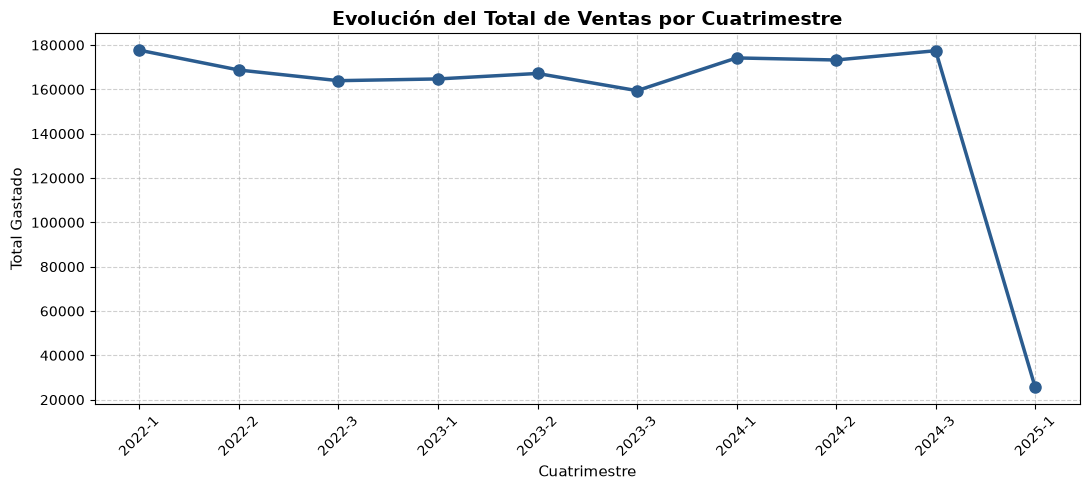

In [483]:
# Gráfico de ventas por tiempo

# 2. Asignar cuatrimestre
cuatrimestre = (df['transaction_date'].dt.month - 1) // 4 + 1
df['cuatrimestre'] = (
    df['transaction_date'].dt.year.astype(str) + '-' + cuatrimestre.astype(str)
)

# 3. Agrupar y ordenar
ventas_cuatrimestre = (
    df.groupby('cuatrimestre')['total_spent'].sum().sort_index()
)

# 4. Graficar
plt.figure(figsize=(11, 5))
plt.plot(
    ventas_cuatrimestre.index,
    ventas_cuatrimestre.values,
    marker='o',
    color='#2b5c8f',
    linewidth=2.5,
    markersize=8,
)

# Personalización de títulos y red
plt.title(
    'Evolución del Total de Ventas por Cuatrimestre',
    fontsize=14,
    fontweight='bold',
)
plt.xlabel('Cuatrimestre', fontsize=11)
plt.ylabel('Total Gastado', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

# Forzar a mostrar TODOS los periodos y rotarlos para legibilidad
plt.xticks(
    ticks=range(len(ventas_cuatrimestre)),
    labels=ventas_cuatrimestre.index,
    rotation=45,
)

plt.tight_layout()
plt.show()

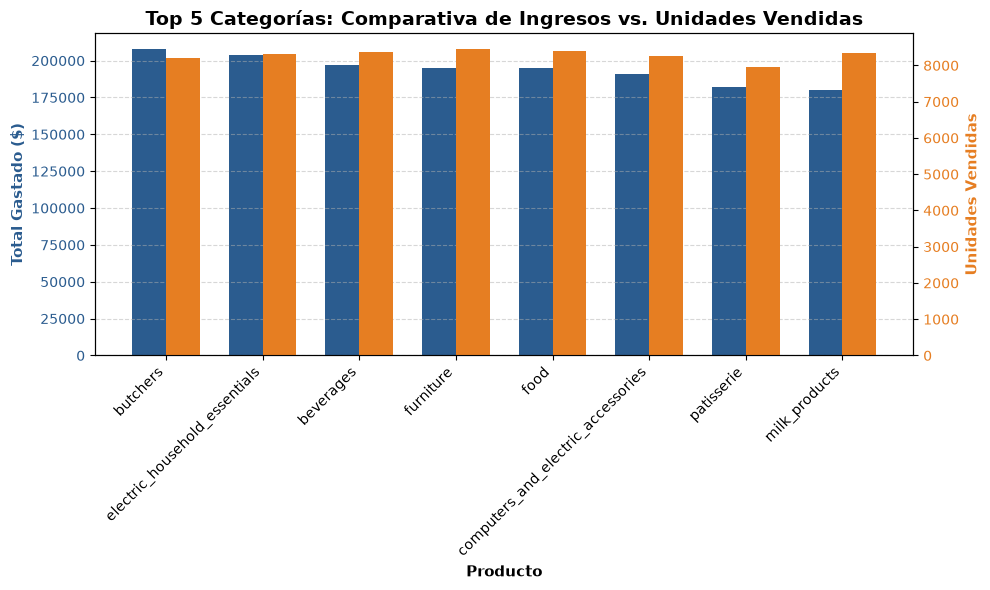

In [484]:
# 1. Agrupar por producto calculando el total gastado y la cantidad vendida
agrupado = df.groupby('category').agg(
    {'total_spent': 'sum', 'quantity': 'sum'}
)

# 2. Seleccionar el Top 5 basado en 'total_spent'
top5 = agrupado.sort_values(by='total_spent', ascending=False)

# 3. Crear la figura y el primer eje (Total Gastado en $)
fig, ax1 = plt.subplots(figsize=(10, 6))

color_dinero = '#2b5c8f'
ax1.set_xlabel('Producto', fontsize=11, fontweight='bold')
ax1.set_ylabel('Total Gastado ($)', color=color_dinero, fontsize=11, fontweight='bold')
barras1 = ax1.bar(top5.index, top5['total_spent'], color=color_dinero, width=-0.35, align='edge', label='Total ($)')
ax1.tick_params(axis='y', labelcolor=color_dinero)
plt.xticks(rotation=45, ha='right')

# 4. Crear el segundo eje Y (Cantidad de Unidades)
ax2 = ax1.twinx()  
color_unidades = '#e67e22'
ax2.set_ylabel('Unidades Vendidas', color=color_unidades, fontsize=11, fontweight='bold')
barras2 = ax2.bar(top5.index, top5['quantity'], color=color_unidades, width=0.35, align='edge', label='Unidades')
ax2.tick_params(axis='y', labelcolor=color_unidades)

# 5. Títulos y ajustes finales
plt.title('Top 5 Categorías: Comparativa de Ingresos vs. Unidades Vendidas', fontsize=14, fontweight='bold')
ax1.grid(axis='y', linestyle='--', alpha=0.5)

fig.tight_layout()
plt.show()

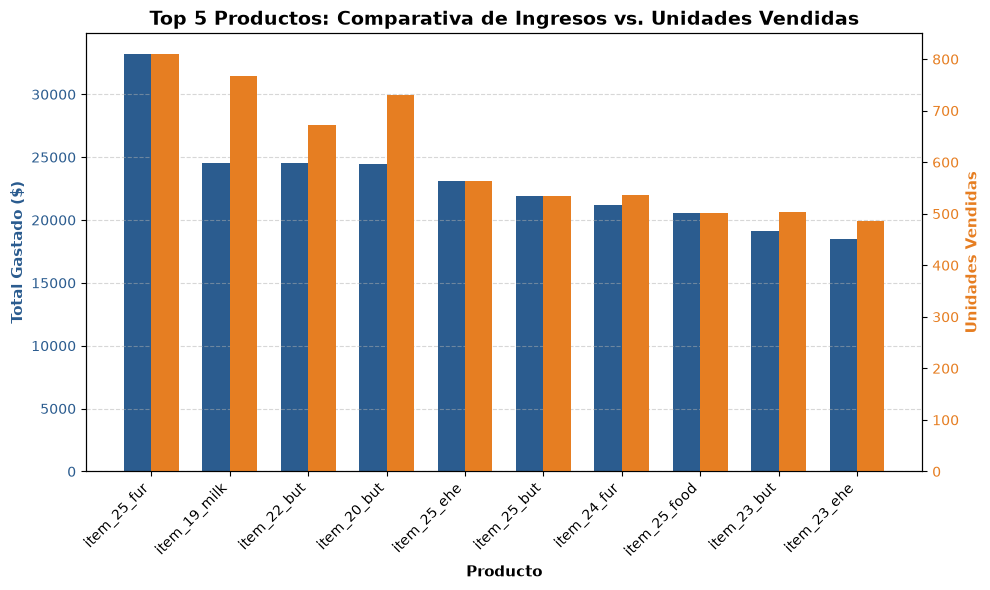

In [485]:
# 1. Agrupar por producto calculando el total gastado y la cantidad vendida
agrupado = df.groupby('item').agg(
    {'total_spent': 'sum', 'quantity': 'sum'}
)

# 2. Seleccionar el Top 5 basado en 'total_spent'
top5 = agrupado.sort_values(by='total_spent', ascending=False).head(10)

# 3. Crear la figura y el primer eje (Total Gastado en $)
fig, ax1 = plt.subplots(figsize=(10, 6))

color_dinero = '#2b5c8f'
ax1.set_xlabel('Producto', fontsize=11, fontweight='bold')
ax1.set_ylabel('Total Gastado ($)', color=color_dinero, fontsize=11, fontweight='bold')
barras1 = ax1.bar(top5.index, top5['total_spent'], color=color_dinero, width=-0.35, align='edge', label='Total ($)')
ax1.tick_params(axis='y', labelcolor=color_dinero)
plt.xticks(rotation=45, ha='right')

# 4. Crear el segundo eje Y (Cantidad de Unidades)
ax2 = ax1.twinx()  
color_unidades = '#e67e22'
ax2.set_ylabel('Unidades Vendidas', color=color_unidades, fontsize=11, fontweight='bold')
barras2 = ax2.bar(top5.index, top5['quantity'], color=color_unidades, width=0.35, align='edge', label='Unidades')
ax2.tick_params(axis='y', labelcolor=color_unidades)

# 5. Títulos y ajustes finales
plt.title('Top 5 Productos: Comparativa de Ingresos vs. Unidades Vendidas', fontsize=14, fontweight='bold')
ax1.grid(axis='y', linestyle='--', alpha=0.5)

fig.tight_layout()
plt.show()

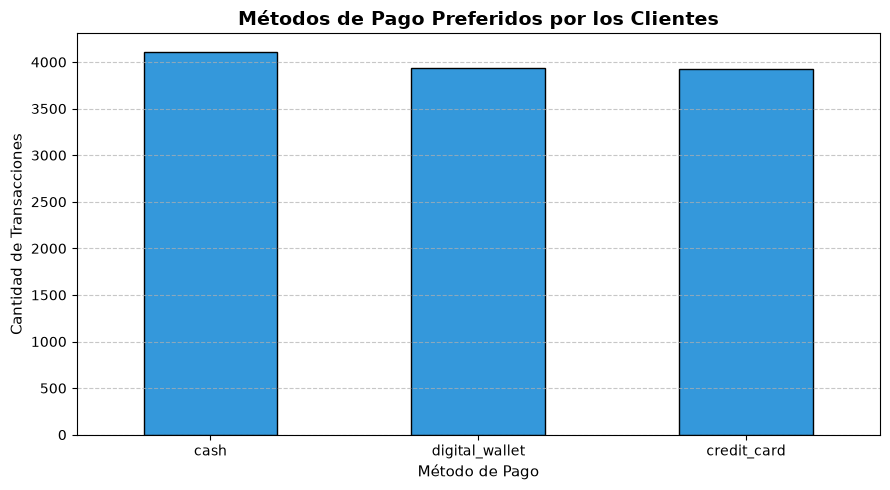

In [486]:
metodo_de_pago_preferido = (
    df.groupby('payment_method').size().sort_values(ascending=False)
)

# O alternativamente:
# metodo_de_pago_preferido = df['payment_method'].value_counts()

# 2. Configurar la figura
plt.figure(figsize=(9, 5))

# 3. Graficar en barras
metodo_de_pago_preferido.plot(kind='bar', color='#3498db', edgecolor='black')

# 4. Personalización
plt.title(
    'Métodos de Pago Preferidos por los Clientes',
    fontsize=14,
    fontweight='bold',
)
plt.xlabel('Método de Pago', fontsize=11)
plt.ylabel('Cantidad de Transacciones', fontsize=11)
plt.xticks(rotation=0)  # Mantiene el texto horizontal si son pocas categorías
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

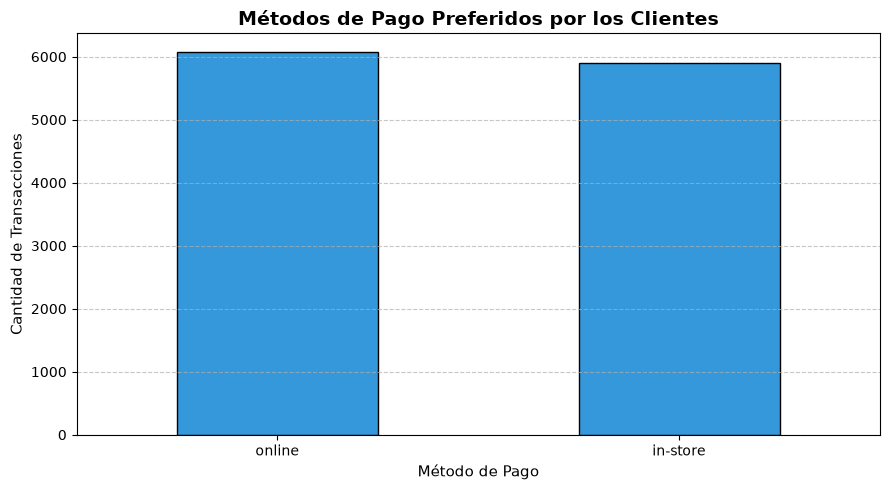

In [487]:
locacion_preferida = (
    df.groupby('location').size().sort_values(ascending=False)
)

# O alternativamente:
# metodo_de_pago_preferido = df['payment_method'].value_counts()

# 2. Configurar la figura
plt.figure(figsize=(9, 5))

# 3. Graficar en barras
locacion_preferida.plot(kind='bar', color='#3498db', edgecolor='black')

# 4. Personalización
plt.title(
    'Métodos de Pago Preferidos por los Clientes',
    fontsize=14,
    fontweight='bold',
)
plt.xlabel('Método de Pago', fontsize=11)
plt.ylabel('Cantidad de Transacciones', fontsize=11)
plt.xticks(rotation=0)  # Mantiene el texto horizontal si son pocas categorías
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

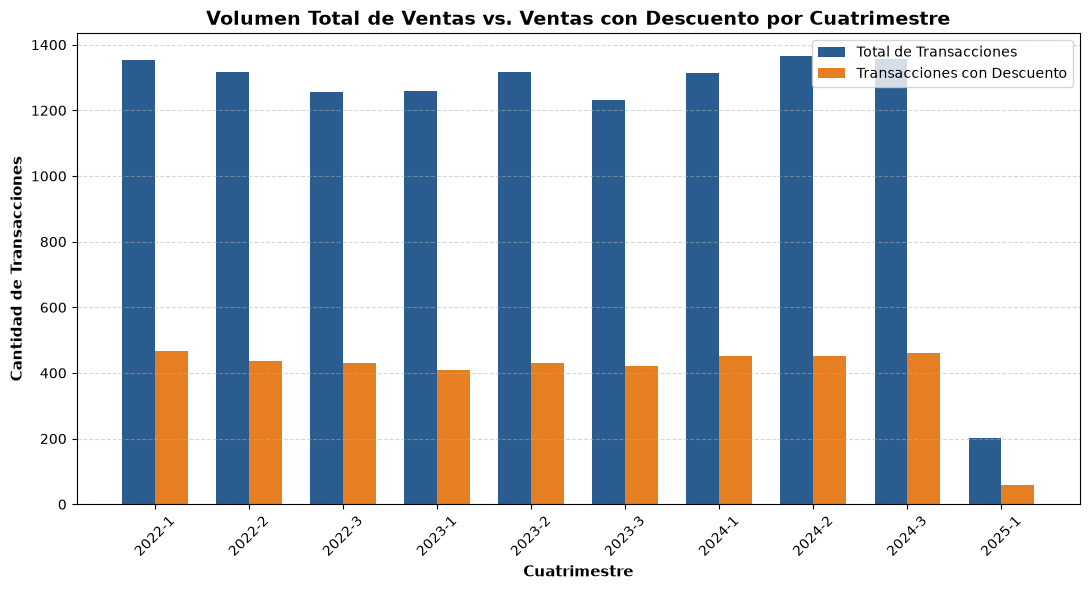

In [488]:
# 1. Contar el total de ventas y las ventas con descuento por cuatrimestre
ventas_totales = df.groupby('cuatrimestre').size()
conteo_descuentos = (
    df[df['discount_applied'] == True].groupby('cuatrimestre').size()
)

# Reindexar para asegurar que ambos tengan los mismos cuatrimestres (rellenando con 0 si alguno no tuvo descuentos)
conteo_descuentos = conteo_descuentos.reindex(
    ventas_totales.index, fill_value=0
)

# 2. Configurar posiciones de las barras agrupadas
x = np.arange(len(ventas_totales))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))

# 3. Graficar ambas barras lado a lado
barras1 = ax.bar(
    x - width / 2,
    ventas_totales.values,
    width,
    label='Total de Transacciones',
    color='#2b5c8f',
)
barras2 = ax.bar(
    x + width / 2,
    conteo_descuentos.values,
    width,
    label='Transacciones con Descuento',
    color='#e67e22',
)

# 4. Personalización del gráfico
ax.set_title(
    'Volumen Total de Ventas vs. Ventas con Descuento por Cuatrimestre',
    fontsize=14,
    fontweight='bold',
)
ax.set_xlabel('Cuatrimestre', fontsize=11, fontweight='bold')
ax.set_ylabel('Cantidad de Transacciones', fontsize=11, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(ventas_totales.index, rotation=45)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()